In [103]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [104]:
df = pd.read_csv("../data/india_housing_prices.csv")
df.head()


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [105]:
df.shape


(250000, 23)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [107]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [108]:
df["Price_in_Lakhs"].describe()

count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

In [109]:
df["Size_in_SqFt"].describe()

count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

In [110]:
df.isnull().sum().sort_values(ascending=False)

ID                                0
Total_Floors                      0
Owner_Type                        0
Facing                            0
Amenities                         0
Security                          0
Parking_Space                     0
Public_Transport_Accessibility    0
Nearby_Hospitals                  0
Nearby_Schools                    0
Age_of_Property                   0
Floor_No                          0
State                             0
Furnished_Status                  0
Year_Built                        0
Price_per_SqFt                    0
Price_in_Lakhs                    0
Size_in_SqFt                      0
BHK                               0
Property_Type                     0
Locality                          0
City                              0
Availability_Status               0
dtype: int64

In [111]:
df_clean = df.copy()

In [112]:
df_clean.duplicated().sum()

0

In [113]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)


Numerical Columns:
 Index(['ID', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
       'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals'],
      dtype='object')

Categorical Columns:
 Index(['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security',
       'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'],
      dtype='object')


In [114]:
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors='coerce')

In [115]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [116]:
df_clean["Age_of_Property"].describe()

count    250000.000000
mean         18.479988
std           9.808575
min           2.000000
25%          10.000000
50%          18.000000
75%          27.000000
max          35.000000
Name: Age_of_Property, dtype: float64

In [117]:
df_clean["Price_per_SqFt"].describe()


count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
Name: Price_per_SqFt, dtype: float64

In [118]:
df_clean.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


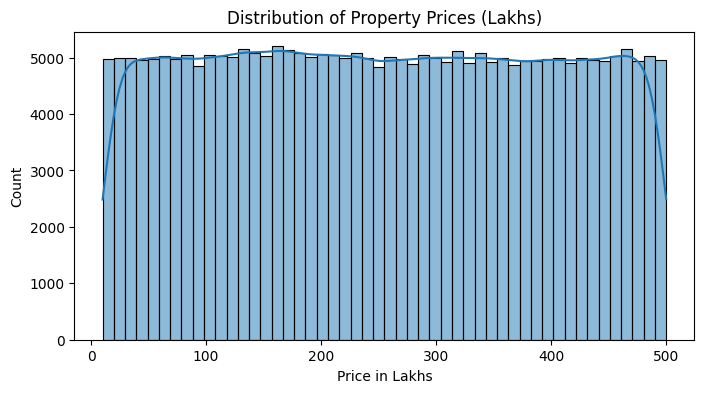

In [119]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["Price_in_Lakhs"], bins=50, kde=True)
plt.title("Distribution of Property Prices (Lakhs)")
plt.xlabel("Price in Lakhs")
plt.ylabel("Count")
plt.show()

In [120]:
df_clean["Price_in_Lakhs"].value_counts(bins=10).sort_index()

(9.509, 59.0]     24894
(59.0, 108.0]     24952
(108.0, 157.0]    25299
(157.0, 206.0]    25465
(206.0, 255.0]    24945
(255.0, 304.0]    24900
(304.0, 353.0]    24943
(353.0, 402.0]    24725
(402.0, 451.0]    24789
(451.0, 500.0]    25088
Name: count, dtype: int64

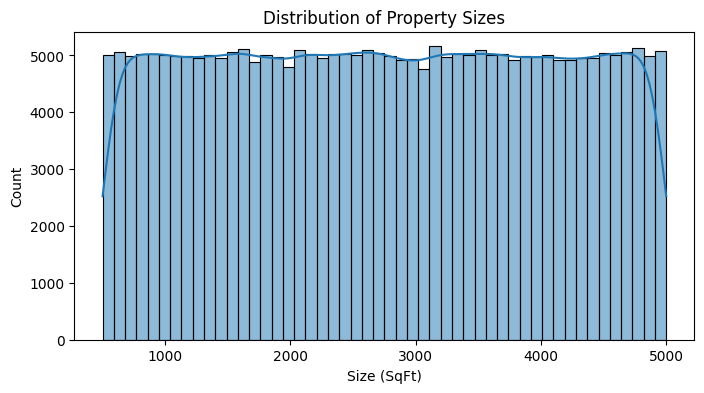

In [121]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["Size_in_SqFt"], bins=50, kde=True)
plt.title("Distribution of Property Sizes")
plt.xlabel("Size (SqFt)")
plt.ylabel("Count")
plt.show()

“Property sizes are uniformly distributed across the dataset, indicating balanced representation of small to large properties. This design reduces size-driven price bias and allows other features such as location and amenities to play a stronger role in price prediction.”

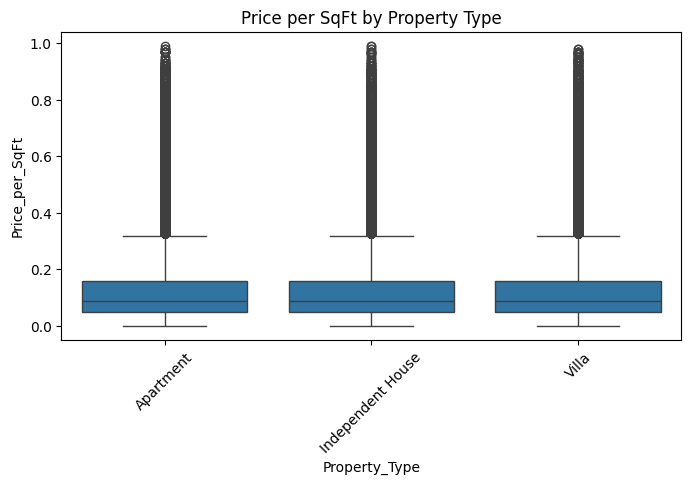

In [122]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Property_Type", y="Price_per_SqFt", data=df_clean)
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.show()

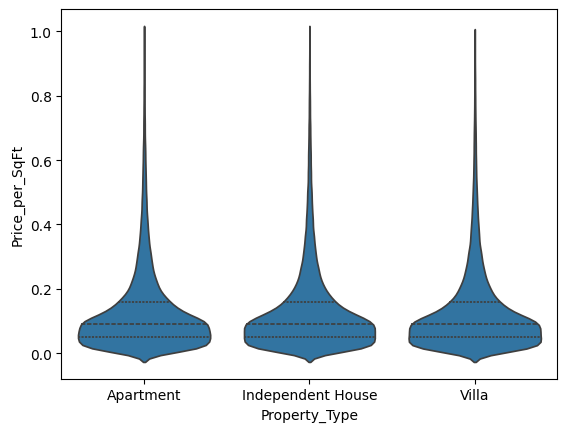

In [123]:
sns.violinplot(
    x="Property_Type",
    y="Price_per_SqFt",
    data=df_clean,
    inner="quartile"
)
plt.show()

In [124]:
df_clean.groupby("Property_Type")["Price_per_SqFt"].median()

Property_Type
Apartment            0.09
Independent House    0.09
Villa                0.09
Name: Price_per_SqFt, dtype: float64

In [125]:
df_clean.groupby("Property_Type")["Price_per_SqFt"].mean()

Property_Type
Apartment            0.130493
Independent House    0.131023
Villa                0.130276
Name: Price_per_SqFt, dtype: float64

“Price per square foot shows nearly identical median and mean values across Apartments, Independent Houses, and Villas. The violin plot reveals a similar distribution shape for all property types, with density significantly decreasing beyond ₹20,000 per sqft. This indicates that property type alone does not significantly influence pricing, and premium pricing is more dependent on other factors such as location and amenities.”

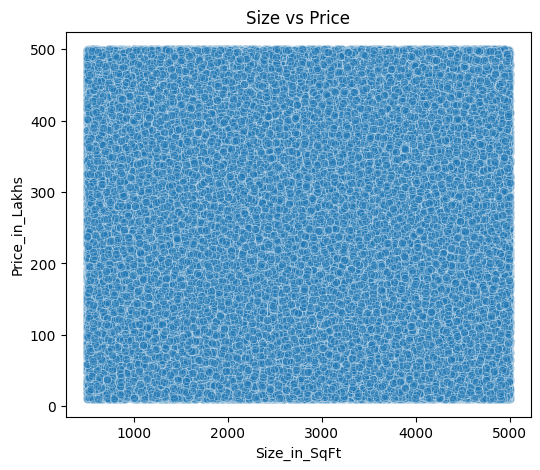

In [126]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    data=df_clean,
    alpha=0.4
)
plt.title("Size vs Price")
plt.show()

In [127]:
df_clean[["Size_in_SqFt", "Price_in_Lakhs"]].corr()

,Size_in_SqFt,Price_in_Lakhs
Size_in_SqFt,1.000000,-0.002529
Price_in_Lakhs,-0.002529,1.000000


“The scatter plot between property size and price does not exhibit a clear trend, appearing as a uniformly filled region. This indicates a weak correlation between size and price in the dataset, suggesting that pricing is influenced more by other factors such as location and amenities rather than size alone.”

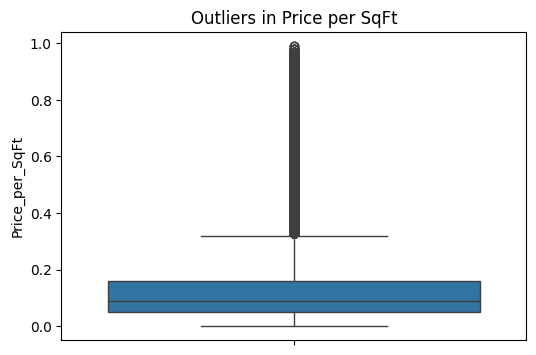

In [128]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_clean["Price_per_SqFt"])
plt.title("Outliers in Price per SqFt")
plt.show()

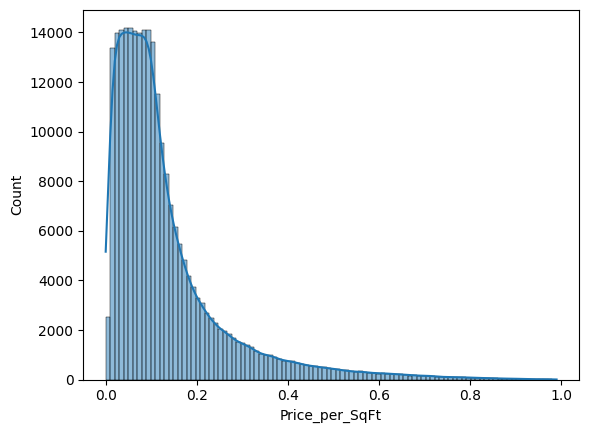

In [129]:
sns.histplot(df_clean["Price_per_SqFt"], bins=100, kde=True)
plt.show()

“The distribution of price per square foot is right-skewed, with the majority of properties priced below ₹20,000 per sqft. The frequency of properties decreases as price per sqft increases, indicating a smaller premium and luxury segment. This explains the presence of high-value points in boxplots, which represent valid market extremes rather than anomalies.”

In [130]:
state_avg_price = (
    df_clean.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

state_avg_price

State
Karnataka         0.132538
Andhra Pradesh    0.132037
Uttar Pradesh     0.131417
Tamil Nadu        0.131367
Gujarat           0.130995
Telangana         0.130957
Assam             0.130819
Madhya Pradesh    0.130717
Maharashtra       0.130703
Haryana           0.130692
West Bengal       0.130645
Bihar             0.130513
Odisha            0.130322
Uttarakhand       0.130245
Chhattisgarh      0.130243
Kerala            0.129849
Jharkhand         0.129754
Delhi             0.129477
Rajasthan         0.129336
Punjab            0.129311
Name: Price_per_SqFt, dtype: float64

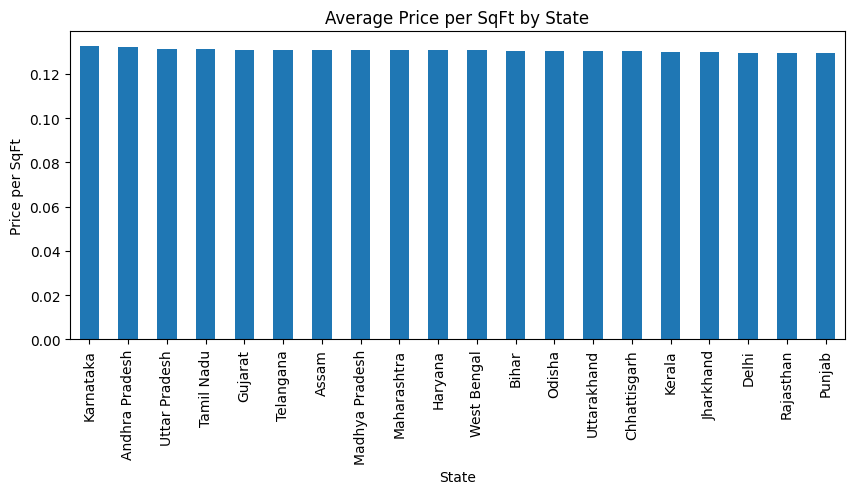

In [131]:
plt.figure(figsize=(10,4))
state_avg_price.plot(kind="bar")
plt.title("Average Price per SqFt by State")
plt.ylabel("Price per SqFt")
plt.show()

In [132]:
city_avg_price = (
    df_clean.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

city_avg_price.head(10)

City
Bangalore     258.456639
Surat         258.080467
Kochi         257.415221
Gaya          257.053391
Mangalore     256.920925
Dehradun      256.890115
Mysore        256.848172
Chennai       256.830172
Hyderabad     256.594051
Coimbatore    256.504745
Name: Price_in_Lakhs, dtype: float64

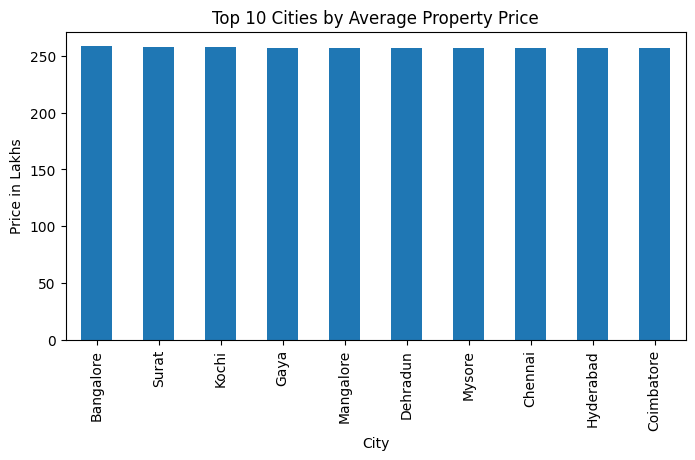

In [133]:
plt.figure(figsize=(8,4))
city_avg_price.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Average Property Price")
plt.ylabel("Price in Lakhs")
plt.show()

In [134]:
locality_median_age = (
    df_clean.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values()
)

locality_median_age.head(10)

Locality
Locality_443    16.0
Locality_468    17.0
Locality_312    17.0
Locality_46     17.0
Locality_13     17.0
Locality_458    17.0
Locality_92     17.0
Locality_454    17.0
Locality_290    17.0
Locality_450    17.0
Name: Age_of_Property, dtype: float64

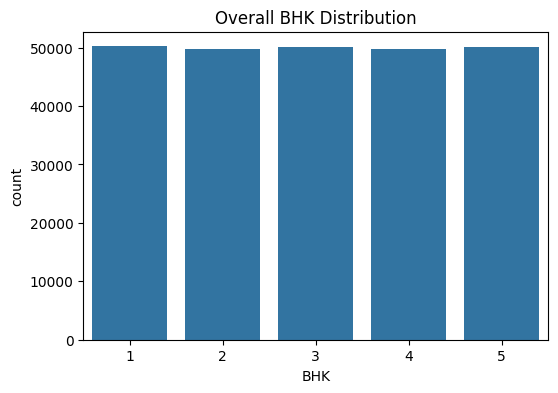

In [135]:
plt.figure(figsize=(6,4))
sns.countplot(x="BHK", data=df_clean)
plt.title("Overall BHK Distribution")
plt.show()

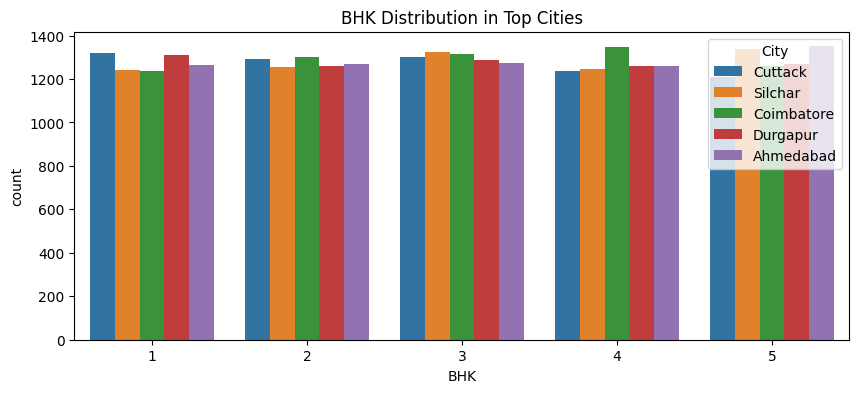

In [136]:
top_cities = df_clean["City"].value_counts().head(5).index

plt.figure(figsize=(10,4))
sns.countplot(
    data=df_clean[df_clean["City"].isin(top_cities)],
    x="BHK",
    hue="City"
)
plt.title("BHK Distribution in Top Cities")
plt.show()

In [137]:
top_localities = (
    df_clean.groupby("Locality")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_localities

Locality
Locality_207    0.152141
Locality_416    0.147866
Locality_246    0.145784
Locality_359    0.144687
Locality_387    0.144398
Name: Price_per_SqFt, dtype: float64

📊 EDA – Questions 11 to 15

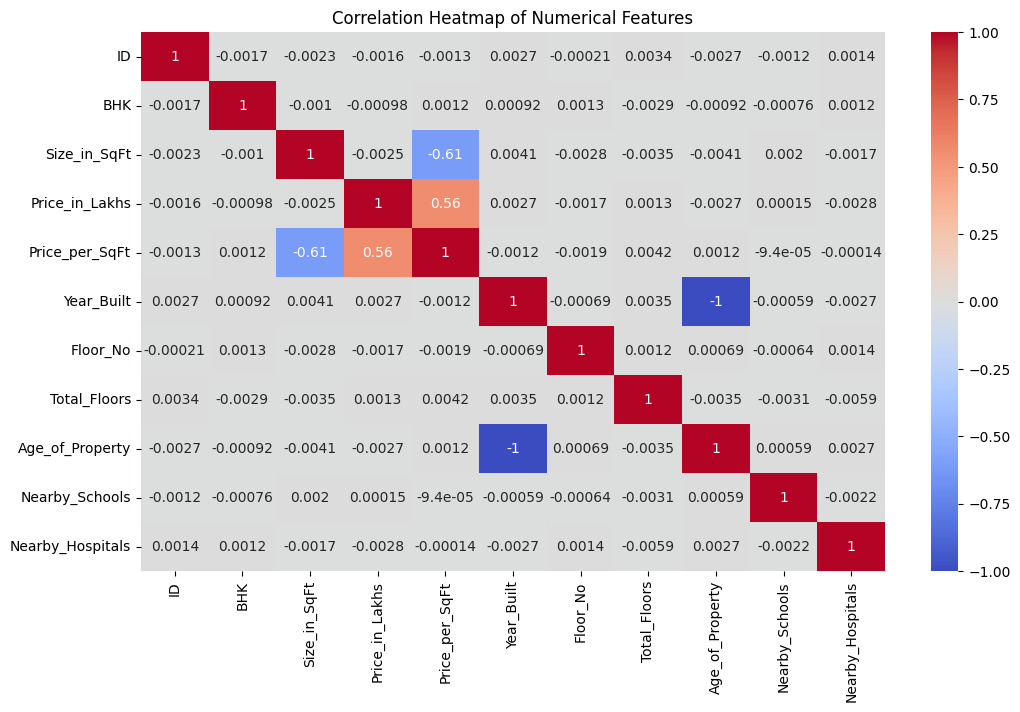

In [138]:
plt.figure(figsize=(12,7))
sns.heatmap(
    df_clean[num_cols].corr(),
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

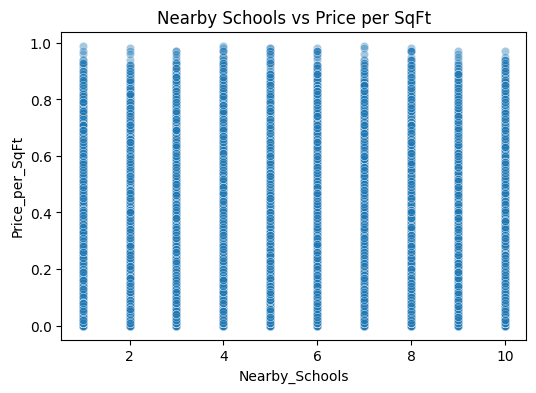

In [139]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Nearby_Schools",
    y="Price_per_SqFt",
    data=df_clean,
    alpha=0.4
)
plt.title("Nearby Schools vs Price per SqFt")
plt.show()

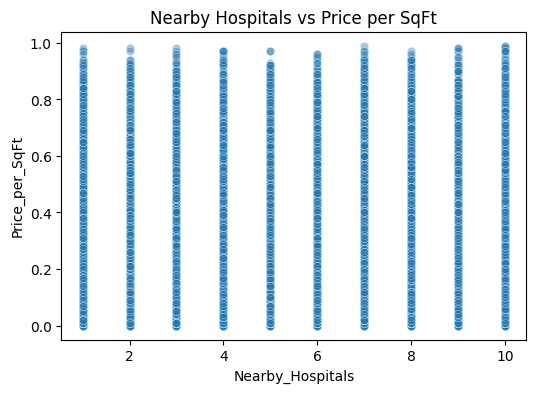

In [140]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Nearby_Hospitals",
    y="Price_per_SqFt",
    data=df_clean,
    alpha=0.4
)
plt.title("Nearby Hospitals vs Price per SqFt")
plt.show()

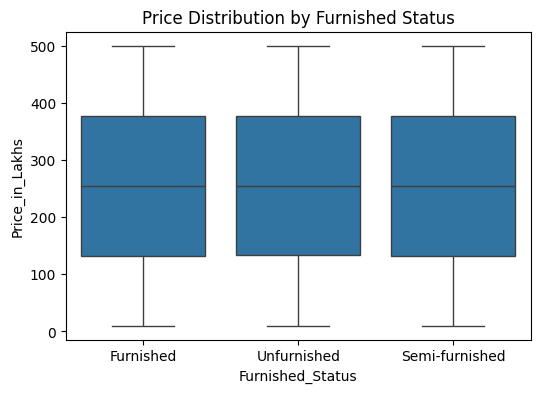

In [141]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Furnished_Status",
    y="Price_in_Lakhs",
    data=df_clean
)
plt.title("Price Distribution by Furnished Status")
plt.show()

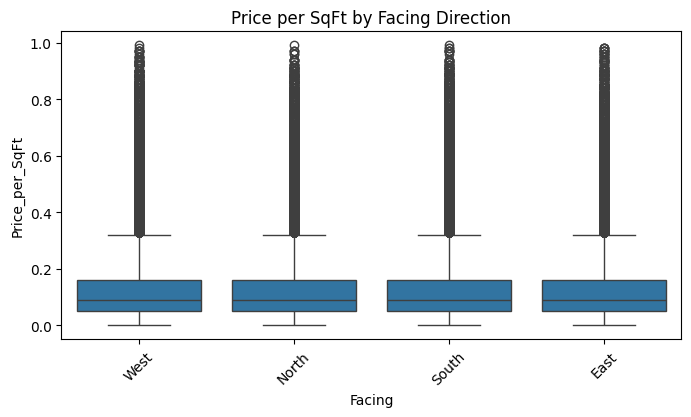

In [142]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x="Facing",
    y="Price_per_SqFt",
    data=df_clean
)
plt.xticks(rotation=45)
plt.title("Price per SqFt by Facing Direction")
plt.show()

In [143]:
df_clean["Owner_Type"].value_counts()

Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64

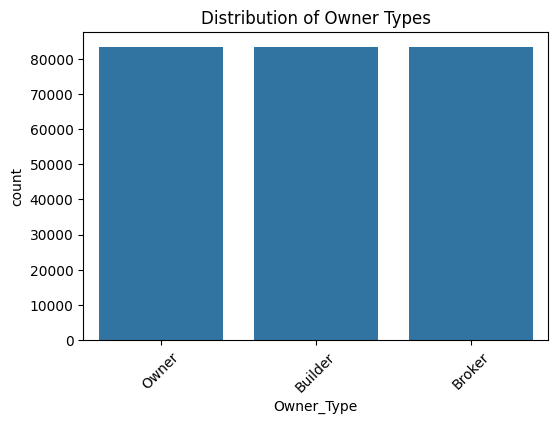

In [144]:
plt.figure(figsize=(6,4))
sns.countplot(x="Owner_Type", data=df_clean)
plt.title("Distribution of Owner Types")
plt.xticks(rotation=45)
plt.show()

In [145]:
df_clean["Availability_Status"].value_counts()

Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64

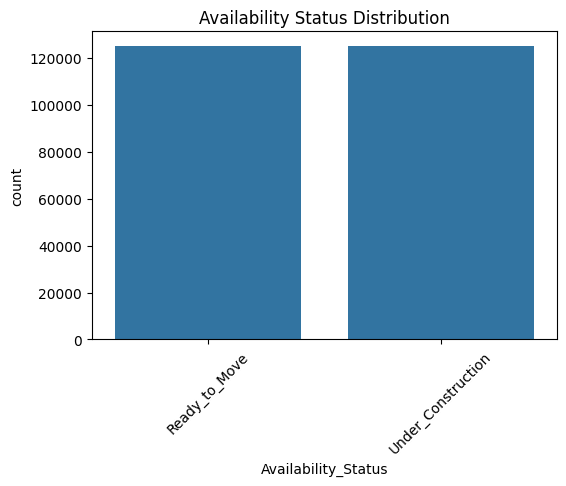

In [146]:
plt.figure(figsize=(6,4))
sns.countplot(x="Availability_Status", data=df_clean)
plt.title("Availability Status Distribution")
plt.xticks(rotation=45)
plt.show()

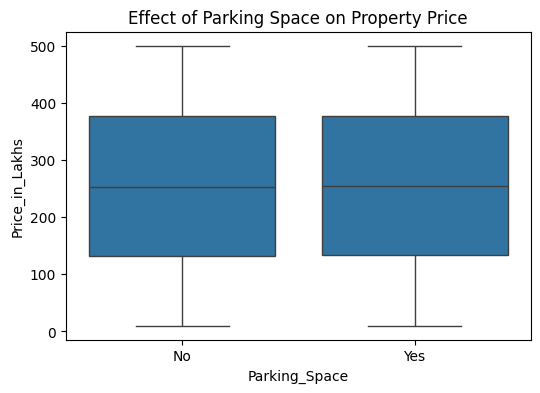

In [147]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Parking_Space",
    y="Price_in_Lakhs",
    data=df_clean
)
plt.title("Effect of Parking Space on Property Price")
plt.show()

In [148]:
df_clean.groupby("Parking_Space")["Price_in_Lakhs"].mean()

Parking_Space
No     254.429369
Yes    254.745492
Name: Price_in_Lakhs, dtype: float64

In [149]:
df_clean["Amenity_Count"] = df_clean["Amenities"].apply(
    lambda x: len(x.split(",")) if x != "none" else 0
)

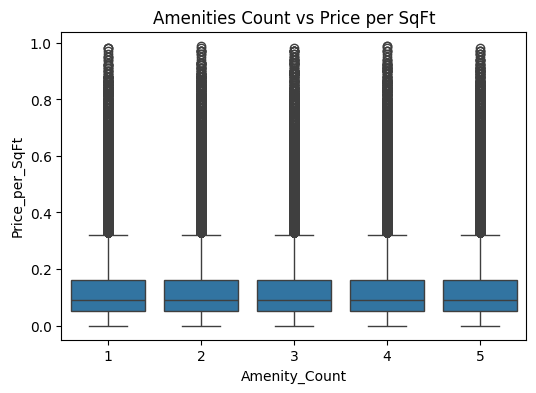

In [150]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Amenity_Count",
    y="Price_per_SqFt",
    data=df_clean
)
plt.title("Amenities Count vs Price per SqFt")
plt.show()

In [151]:
df_clean.groupby("Amenity_Count")["Price_per_SqFt"].mean()

Amenity_Count
1    0.130172
2    0.130597
3    0.130454
4    0.130717
5    0.131045
Name: Price_per_SqFt, dtype: float64

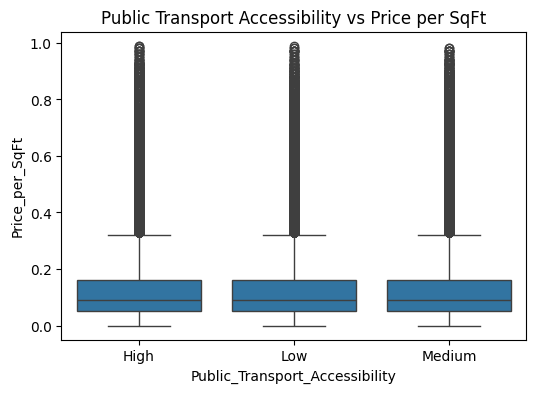

In [152]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Public_Transport_Accessibility",
    y="Price_per_SqFt",
    data=df_clean
)
plt.title("Public Transport Accessibility vs Price per SqFt")
plt.show()

In [153]:
df_clean.groupby("Public_Transport_Accessibility")["Price_per_SqFt"].mean()

Public_Transport_Accessibility
High      0.130286
Low       0.130874
Medium    0.130632
Name: Price_per_SqFt, dtype: float64

In [154]:
df_clean["Amenities"].unique()

array(['Playground, Gym, Garden, Pool, Clubhouse',
       'Playground, Clubhouse, Pool, Gym, Garden',
       'Clubhouse, Pool, Playground, Gym',
       'Playground, Clubhouse, Gym, Pool, Garden',
       'Playground, Garden, Gym, Pool, Clubhouse',
       'Playground, Clubhouse', 'Clubhouse, Garden, Playground',
       'Gym, Pool, Clubhouse, Playground',
       'Garden, Clubhouse, Playground',
       'Clubhouse, Playground, Garden, Gym', 'Clubhouse',
       'Clubhouse, Gym, Playground, Pool',
       'Clubhouse, Garden, Gym, Playground, Pool',
       'Garden, Gym, Playground', 'Playground',
       'Pool, Playground, Garden, Gym', 'Pool, Clubhouse, Gym',
       'Garden, Clubhouse, Pool, Gym, Playground',
       'Pool, Playground, Clubhouse',
       'Clubhouse, Gym, Garden, Pool, Playground',
       'Pool, Clubhouse, Gym, Playground, Garden',
       'Garden, Pool, Gym, Playground, Clubhouse', 'Pool, Gym, Clubhouse',
       'Clubhouse, Garden', 'Pool, Garden, Playground, Gym',
       'Garden

In [155]:
df_clean["Amenities"] = (
    df_clean["Amenities"]
    .fillna("none")
    .str.lower()
    .str.strip()
)

In [156]:
unique_amenities = (
    df_clean["Amenities"]
    .str.split(",")
    .explode()
    .str.strip()
    .unique()
)

In [157]:
unique_amenities

array(['playground', 'gym', 'garden', 'pool', 'clubhouse'], dtype=object)

In [158]:
for amenity in unique_amenities:
    df_clean[f"Has_{amenity.capitalize()}"] = (
        df_clean["Amenities"]
        .str.contains(amenity, regex=False)
        .astype(int)
    )

In [159]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [160]:
df_clean.Furnished_Status.unique()

array(['Furnished', 'Unfurnished', 'Semi-furnished'], dtype=object)

In [161]:
furnish_map = {
    "Unfurnished": 0,
    "Semi-furnished": 1,
    "Furnished": 2
}

df_clean["Furnish_Score"] = (
    df_clean["Furnished_Status"]
    .map(furnish_map)
)

In [162]:
df_clean["Furnish_Score"].value_counts()

Furnish_Score
0    83408
1    83374
2    83218
Name: count, dtype: int64

In [163]:
df_clean.Public_Transport_Accessibility.unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [164]:
transport_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

df_clean["Transport_Score"] = (
    df_clean["Public_Transport_Accessibility"]
    .str.lower()
    .map(transport_map)
)

In [165]:
df_clean["Transport_Score"].value_counts()

Transport_Score
3    83705
1    83287
2    83008
Name: count, dtype: int64

In [166]:
drop_cols = [
    "Amenities",
    "Furnished_Status",
    "Public_Transport_Accessibility"
]

df_clean.drop(columns=drop_cols, inplace=True)

In [167]:
df_clean.Locality.unique()

array(['Locality_84', 'Locality_490', 'Locality_167', 'Locality_393',
       'Locality_466', 'Locality_246', 'Locality_254', 'Locality_232',
       'Locality_122', 'Locality_75', 'Locality_462', 'Locality_227',
       'Locality_287', 'Locality_148', 'Locality_369', 'Locality_265',
       'Locality_50', 'Locality_385', 'Locality_241', 'Locality_286',
       'Locality_74', 'Locality_459', 'Locality_355', 'Locality_151',
       'Locality_159', 'Locality_382', 'Locality_143', 'Locality_454',
       'Locality_262', 'Locality_136', 'Locality_223', 'Locality_368',
       'Locality_480', 'Locality_485', 'Locality_398', 'Locality_305',
       'Locality_114', 'Locality_202', 'Locality_96', 'Locality_295',
       'Locality_58', 'Locality_484', 'Locality_323', 'Locality_432',
       'Locality_273', 'Locality_458', 'Locality_150', 'Locality_238',
       'Locality_494', 'Locality_464', 'Locality_431', 'Locality_125',
       'Locality_218', 'Locality_112', 'Locality_27', 'Locality_40',
       'Locali

In [168]:
locality_price_map = (
    df_clean.groupby("Locality")["Price_per_SqFt"]
    .mean()
)

In [169]:
df_clean["Locality_Price_Score"] = df_clean["Locality"].map(locality_price_map)

In [170]:
df_clean["Locality_Price_Score"].head()

0    0.123533
1    0.130505
2    0.134941
3    0.118280
4    0.125957
Name: Locality_Price_Score, dtype: float64

In [171]:
df_clean.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Amenity_Count,Has_Playground,Has_Gym,Has_Garden,Has_Pool,Has_Clubhouse,Furnish_Score,Transport_Score,Locality_Price_Score
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,22,1,35,10,3,No,No,West,Owner,Ready_to_Move,5,1,1,1,1,1,2,3,0.123533
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,21,20,17,8,1,No,Yes,North,Builder,Under_Construction,5,1,1,1,1,1,0,1,0.130505
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,19,27,28,9,8,Yes,No,South,Broker,Ready_to_Move,4,1,1,0,1,1,1,1,0.134941
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,21,26,34,5,7,Yes,Yes,North,Builder,Ready_to_Move,5,1,1,1,1,1,2,3,0.118280
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,3,2,23,4,9,No,Yes,East,Builder,Ready_to_Move,5,1,1,1,1,1,1,1,0.125957


In [172]:
city_price_map = (
    df_clean.groupby("City")["Price_per_SqFt"]
    .mean()
)

In [173]:
df_clean["City_Price_Score"] = df_clean["City"].map(city_price_map)

In [174]:
df_clean["City_Price_Score"].head()

0    0.131629
1    0.132973
2    0.129292
3    0.129386
4    0.129286
Name: City_Price_Score, dtype: float64

In [175]:
GROWTH_RATE = 0.08
YEARS = 5

df_clean["Future_Price_5Y"] = (
    df_clean["Price_in_Lakhs"] * ((1 + GROWTH_RATE) ** YEARS)
)

In [176]:
df_clean["Investment_Score"] = (
    (df_clean["Price_per_SqFt"] < df_clean["Locality_Price_Score"]).astype(int) +
    (df_clean["Amenity_Count"] >= 3).astype(int) +
    (df_clean["Transport_Score"] >= 2).astype(int) +
    (df_clean["Age_of_Property"] <= 20).astype(int)
)

In [177]:
df_clean["Good_Investment"] = (
    df_clean["Investment_Score"] >= 3
).astype(int)

In [178]:
df_clean["Good_Investment"].value_counts()

Good_Investment
1    129515
0    120485
Name: count, dtype: int64

In [179]:
feature_cols = [
    "BHK",
    "Size_in_SqFt",
    "Age_of_Property",
    "Price_per_SqFt",
    "Amenity_Count",
    "Has_Playground",
    "Has_Gym",
    "Has_Garden",
    "Has_Pool",
    "Has_Clubhouse",
    "Furnish_Score",
    "Transport_Score",
    "Locality_Price_Score",
    "City_Price_Score"
]

In [180]:
df_clean[feature_cols].isnull().sum()

BHK                     0
Size_in_SqFt            0
Age_of_Property         0
Price_per_SqFt          0
Amenity_Count           0
Has_Playground          0
Has_Gym                 0
Has_Garden              0
Has_Pool                0
Has_Clubhouse           0
Furnish_Score           0
Transport_Score         0
Locality_Price_Score    0
City_Price_Score        0
dtype: int64

In [181]:
X = df_clean[feature_cols]
y_class = df_clean["Good_Investment"]
y_reg = df_clean["Future_Price_5Y"]

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [183]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [184]:
X_train.shape, X_test.shape

((200000, 14), (50000, 14))

In [185]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Classification
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regression
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

In [186]:
X_train_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [187]:
X_train_scaled.mean(axis=0)[:5]


array([-1.81863413e-16, -8.85336249e-17, -5.28643795e-17,  2.02078354e-16,
       -1.69286807e-16])

 Train Logistic Regression

In [220]:
import mlflow
from pathlib import Path

# Project root (outside notebooks)
PROJECT_ROOT = Path.cwd().parent

# MLflow directory
MLFLOW_DIR = PROJECT_ROOT / "mlruns"

# Set tracking URI (Windows-safe)
mlflow.set_tracking_uri(MLFLOW_DIR.as_uri())

# Set experiment (creates it if not exists)
mlflow.set_experiment("Real_Estate_Investment_Project")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: file:///c:/Users/atharva/Desktop/Investment%20advisor/mlruns


In [221]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import mlflow

with mlflow.start_run(run_name="Logistic_Regression_Classification"):

    # Model
    log_reg = LogisticRegression(max_iter=1000)

    # Log parameters
    mlflow.log_params({
        "model": "LogisticRegression",
        "max_iter": 1000,
        "solver": log_reg.solver
    })

    # Train
    log_reg.fit(X_train_scaled, y_train_cls)

    # Predict
    y_pred = log_reg.predict(X_test_scaled)
    y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    roc = roc_auc_score(y_test_cls, y_prob)

    # Log metrics
    mlflow.log_metrics({
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC_AUC": roc
    })

    # Log model
    mlflow.sklearn.log_model(log_reg, "logistic_regression_model")

    # Print for notebook visibility
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("ROC AUC  :", roc)

2026/02/26 16:33:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:33:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.85544
Precision: 0.8571155390675794
Recall   : 0.8651893603057561
ROC AUC  : 0.9356899247773964


In [222]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import mlflow

with mlflow.start_run(run_name="Random_Forest_Classification"):

    # Model
    rf_clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    # Log parameters
    mlflow.log_params({
        "model": "RandomForestClassifier",
        "n_estimators": 200,
        "max_depth": "None",
        "random_state": 42
    })

    # Train
    rf_clf.fit(X_train, y_train_cls)

    # Predict
    y_pred_rf = rf_clf.predict(X_test)
    y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred_rf)
    prec = precision_score(y_test_cls, y_pred_rf)
    rec = recall_score(y_test_cls, y_pred_rf)
    roc = roc_auc_score(y_test_cls, y_prob_rf)

    # Log metrics
    mlflow.log_metrics({
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC_AUC": roc
    })

    # Log model
    mlflow.sklearn.log_model(rf_clf, "random_forest_classification_model")

    # Print results
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("ROC AUC  :", roc)

2026/02/26 16:34:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:34:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.99874
Precision: 0.9986491702045542
Recall   : 0.998919044126163
ROC AUC  : 0.9999950495413623


In [ ]:
import numpy as np

y_shuffled = np.random.permutation(y_train_cls)

rf_test = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_test.fit(X_train, y_shuffled)

y_prob_test = rf_test.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
roc_auc_score(y_test_cls, y_prob_test)
print("Accuracy :", accuracy_score(y_test_cls, y_pred_rf))
print("Precision:", precision_score(y_test_cls, y_pred_rf))
print("Recall   :", recall_score(y_test_cls, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test_cls, y_prob_rf))

0.5128220627605976

Accuracy : 0.99874
Precision: 0.9986491702045542
Recall   : 0.998919044126163
ROC AUC  : 0.9999950495413623


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_cls)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test_cls, y_pred_dt))
print("Precision:", precision_score(y_test_cls, y_pred_dt))
print("Recall   :", recall_score(y_test_cls, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test_cls, y_prob_dt))

In [223]:
import mlflow
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

with mlflow.start_run(run_name="DecisionTree_Classification"):

    # Model
    dt_model = DecisionTreeClassifier(
        random_state=42
    )

    # Log parameters
    mlflow.log_params({
        "model": "DecisionTreeClassifier",
        "criterion": dt_model.criterion,
        "max_depth": dt_model.max_depth,
        "min_samples_split": dt_model.min_samples_split
    })

    # Train
    dt_model.fit(X_train, y_train_cls)

    # Predict
    y_pred_dt = dt_model.predict(X_test)
    y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred_dt)
    prec = precision_score(y_test_cls, y_pred_dt)
    rec = recall_score(y_test_cls, y_pred_dt)
    roc = roc_auc_score(y_test_cls, y_prob_dt)

    # Log metrics
    mlflow.log_metrics({
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC_AUC": roc
    })

    # Log model
    mlflow.sklearn.log_model(dt_model, "decision_tree_model")

    # Print results
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("ROC AUC  :", roc)



2026/02/26 16:37:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:37:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.99994
Precision: 0.999922791846819
Recall   : 0.9999613944330773
ROC AUC  : 0.9999391982747616


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train_cls)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test_cls, y_pred_gb))
print("Precision:", precision_score(y_test_cls, y_pred_gb))
print("Recall   :", recall_score(y_test_cls, y_pred_gb))
print("ROC AUC  :", roc_auc_score(y_test_cls, y_prob_gb))

In [224]:
import mlflow
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

with mlflow.start_run(run_name="GradientBoosting_Classification"):

    # Model
    gb_model = GradientBoostingClassifier(
        random_state=42
    )

    # Log parameters
    mlflow.log_params({
        "model": "GradientBoostingClassifier",
        "n_estimators": gb_model.n_estimators,
        "learning_rate": gb_model.learning_rate,
        "max_depth": gb_model.max_depth if hasattr(gb_model, "max_depth") else None
    })

    # Train
    gb_model.fit(X_train, y_train_cls)

    # Predict
    y_pred_gb = gb_model.predict(X_test)
    y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred_gb)
    prec = precision_score(y_test_cls, y_pred_gb)
    rec = recall_score(y_test_cls, y_pred_gb)
    roc = roc_auc_score(y_test_cls, y_prob_gb)

    # Log metrics
    mlflow.log_metrics({
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC_AUC": roc
    })

    # Log model
    mlflow.sklearn.log_model(gb_model, "gradient_boosting_model")

    # Print results
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("ROC AUC  :", roc)



2026/02/26 16:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:39:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.99852
Precision: 0.9987641447495462
Recall   : 0.9983785661892445
ROC AUC  : 0.9999978467908062


MLflow tracking URI: file:///c:/Users/atharva/Desktop/Investment%20advisor/mlruns


In [217]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import mlflow

with mlflow.start_run(run_name="XGBoost_Classification"):

    xgb_cls = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )

    # Log parameters
    mlflow.log_params({
        "model": "XGBoost_Classifier",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 5
    })

    # Train
    xgb_cls.fit(X_train, y_train_cls)

    # Predict
    y_pred_xgb = xgb_cls.predict(X_test)
    y_prob_xgb = xgb_cls.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred_xgb)
    prec = precision_score(y_test_cls, y_pred_xgb)
    rec = recall_score(y_test_cls, y_pred_xgb)
    roc = roc_auc_score(y_test_cls, y_prob_xgb)

    # Log metrics
    mlflow.log_metrics({
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC_AUC": roc
    })

    # Log model
    mlflow.sklearn.log_model(xgb_cls, "xgb_classification_model")

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("ROC AUC  :", roc)

2026/02/26 15:53:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:53:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.99996
Precision: 0.9999227948272534
Recall   : 1.0
ROC AUC  : 0.9999998269742612


In [225]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest",
              "Decision Tree",
              "Gradient Boosting",
              "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred),
        accuracy_score(y_test_cls, y_pred_rf),
        accuracy_score(y_test_cls, y_pred_dt),
        accuracy_score(y_test_cls, y_pred_gb),
        accuracy_score(y_test_cls, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test_cls, y_pred),
        precision_score(y_test_cls, y_pred_rf),
        precision_score(y_test_cls, y_pred_dt),
        precision_score(y_test_cls, y_pred_gb),
        precision_score(y_test_cls, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test_cls, y_pred),
        recall_score(y_test_cls, y_pred_rf),
        recall_score(y_test_cls, y_pred_dt),
        recall_score(y_test_cls, y_pred_gb),
        recall_score(y_test_cls, y_pred_xgb)
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test_cls, y_prob),
        roc_auc_score(y_test_cls, y_prob_rf),
        roc_auc_score(y_test_cls, y_prob_dt),
        roc_auc_score(y_test_cls, y_prob_gb),
        roc_auc_score(y_test_cls, y_prob_xgb)
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,ROC_AUC
4,XGBoost,0.99996,0.999923,1.000000,1.000000
3,Gradient Boosting,0.99852,0.998764,0.998379,0.999998
1,Random Forest,0.99874,0.998649,0.998919,0.999995
2,Decision Tree,0.99994,0.999923,0.999961,0.999939
0,Logistic Regression,0.85544,0.857116,0.865189,0.935690


In [203]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
rf_importance = pd.Series(rf_clf.feature_importances_, index=X_train.columns)

# Sort
rf_importance = rf_importance.sort_values(ascending=False)

# Display top features
rf_importance.head(10)

Age_of_Property    0.262422
Transport_Score    0.237275
Price_per_SqFt     0.198400
Amenity_Count      0.148772
Size_in_SqFt       0.043275
Has_Playground     0.018771
Has_Garden         0.018406
Has_Pool           0.017647
Has_Clubhouse      0.017187
Has_Gym            0.016308
dtype: float64

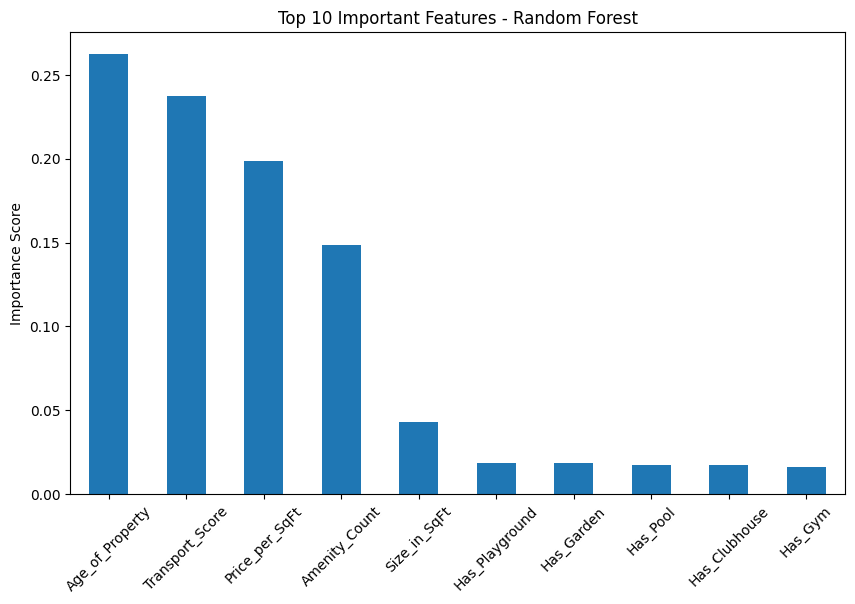

In [204]:
plt.figure(figsize=(10,6))
rf_importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

#Regression model

In [205]:
X_reg = X.copy()  # features
y_reg = df_clean["Future_Price_5Y"]

In [226]:
import mlflow
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with mlflow.start_run(run_name="LinearRegression_Regression"):

    # Model
    lin_reg = LinearRegression()

    # Log parameters
    mlflow.log_params({
        "model": "LinearRegression",
        "fit_intercept": lin_reg.fit_intercept
    })

    # Train
    lin_reg.fit(X_train_reg, y_train_reg)

    # Predict
    y_pred_lin = lin_reg.predict(X_test_reg)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))
    mae = mean_absolute_error(y_test_reg, y_pred_lin)
    r2 = r2_score(y_test_reg, y_pred_lin)

    # Log metrics
    mlflow.log_metrics({
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # Log model
    mlflow.sklearn.log_model(lin_reg, "linear_regression_model")

    # Print results
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

2026/02/26 16:40:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:40:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 148.13602242685323
MAE : 119.22115636623295
R2  : 0.49013341519117426


In [230]:
import mlflow
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with mlflow.start_run(run_name="RandomForest_Regression"):

    # Model
    rf_reg = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # Log parameters
    mlflow.log_params({
        "model": "RandomForestRegressor",
        "n_estimators": 200,
        "random_state": 42
    })

    # Train
    rf_reg.fit(X_train_reg, y_train_reg)

    # Predict
    y_pred_rf_reg = rf_reg.predict(X_test_reg)

    # Metrics
    rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
    mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
    r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

    # Log metrics
    mlflow.log_metrics({
        "RMSE": rmse_rf,
        "MAE": mae_rf,
        "R2": r2_rf
    })

    # Log model
    mlflow.sklearn.log_model(rf_reg, "random_forest_regression_model")

    # Print results
    print("RMSE:", rmse_rf)
    print("MAE :", mae_rf)
    print("R2  :", r2_rf)

2026/02/26 16:56:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:56:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 13.172623608193422
MAE : 10.204752746276748
R2  : 0.9959683784588923


In [231]:
import mlflow
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with mlflow.start_run(run_name="GradientBoosting_Regression"):

    # Model
    gb_reg = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    # Log parameters
    mlflow.log_params({
        "model": "GradientBoostingRegressor",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 5,
        "random_state": 42
    })

    # Train
    gb_reg.fit(X_train_reg, y_train_reg)

    # Predict
    y_pred_gb_reg = gb_reg.predict(X_test_reg)

    # Metrics
    rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
    mae_gb = mean_absolute_error(y_test_reg, y_pred_gb_reg)
    r2_gb = r2_score(y_test_reg, y_pred_gb_reg)

    # Log metrics
    mlflow.log_metrics({
        "RMSE": rmse_gb,
        "MAE": mae_gb,
        "R2": r2_gb
    })

    # Log model
    mlflow.sklearn.log_model(gb_reg, "gradient_boosting_regression_model")

    # Print results
    print("RMSE:", rmse_gb)
    print("MAE :", mae_gb)
    print("R2  :", r2_gb)

2026/02/26 16:57:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:57:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 13.424505438923722
MAE : 10.685757475050575
R2  : 0.9958127221264239


In [233]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import mlflow
with mlflow.start_run(run_name="XGBoost_Regression"):

    xgb_reg = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
    
    # Log parameters
    mlflow.log_params({
        "model": "XGBoost_Regression",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 5,
    })
    

    xgb_reg.fit(X_train_reg, y_train_reg)
    y_pred_xgb_reg = xgb_reg.predict(X_test_reg)
    rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
    mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
    r2_xgb = r2_score(y_test_reg, y_pred_xgb_reg)
    
    # Log metrics
    mlflow.log_metric("RMSE", rmse_xgb)
    mlflow.log_metric("MAE", mae_xgb)
    mlflow.log_metric("R2", r2_xgb)
    
    print("RMSE:", rmse_xgb)
    print("MAE :", mae_xgb)
    print("R2  :", r2_xgb)
      
    # Save model
    mlflow.sklearn.log_model(xgb_reg, "xgb_regression_model")

2026/02/26 17:05:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 17:05:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 13.176697893663755
MAE : 10.45151416722644
R2  : 0.9959658841164092


In [232]:
import mlflow
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with mlflow.start_run(run_name="ExtraTrees_Regression"):

    # Model
    et_reg = ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # Log parameters
    mlflow.log_params({
        "model": "ExtraTreesRegressor",
        "n_estimators": 200,
        "random_state": 42
    })

    # Train
    et_reg.fit(X_train_reg, y_train_reg)

    # Predict
    y_pred_et = et_reg.predict(X_test_reg)

    # Metrics
    rmse_et = np.sqrt(mean_squared_error(y_test_reg, y_pred_et))
    mae_et = mean_absolute_error(y_test_reg, y_pred_et)
    r2_et = r2_score(y_test_reg, y_pred_et)

    # Log metrics
    mlflow.log_metrics({
        "RMSE": rmse_et,
        "MAE": mae_et,
        "R2": r2_et
    })

    # Log model
    mlflow.sklearn.log_model(et_reg, "extra_trees_regression_model")

    # Print results
    print("RMSE:", rmse_et)
    print("MAE :", mae_et)
    print("R2  :", r2_et)

2026/02/26 16:58:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:58:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 13.419071077922055
MAE : 10.331053645820903
R2  : 0.9958161115360273


In [212]:
import pandas as pd

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Extra Trees"
    ],
    
    "RMSE": [
        rmse,
        rmse_rf,
        rmse_gb,
        rmse_xgb,
        rmse_et
    ],
    
    "MAE": [
        mae,
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_et
    ],
    
    "R2": [
        r2,
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_et
    ]
})

# Sort results
regression_results.sort_values(by="R2", ascending=False)

,Model,RMSE,MAE,R2
1,Random Forest,13.172624,10.204753,0.995968
3,XGBoost,13.176698,10.451514,0.995966
4,Extra Trees,13.419071,10.331054,0.995816
2,Gradient Boosting,13.424505,10.685757,0.995813
0,Linear Regression,148.136022,119.221156,0.490133


In [213]:
rf_reg_importance = pd.Series(rf_reg.feature_importances_, index=X_train_reg.columns)
rf_reg_importance = rf_reg_importance.sort_values(ascending=False)

rf_reg_importance.head(10)

Price_per_SqFt          0.806206
Size_in_SqFt            0.190823
Locality_Price_Score    0.000730
City_Price_Score        0.000577
Age_of_Property         0.000553
BHK                     0.000246
Amenity_Count           0.000193
Transport_Score         0.000157
Furnish_Score           0.000153
Has_Garden              0.000074
dtype: float64

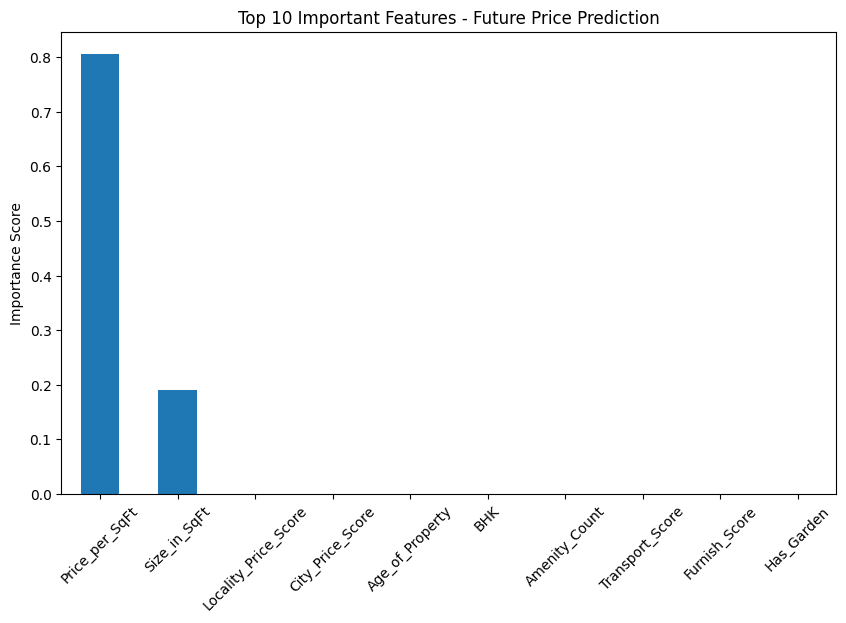

In [214]:
plt.figure(figsize=(10,6))
rf_reg_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features - Future Price Prediction")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [219]:

import joblib

joblib.dump(xgb_cls, "../models/classification_model.pkl")
joblib.dump(xgb_reg, "../models/regression_model.pkl")

['../models/regression_model.pkl']

In [234]:
import mlflow

# Replace with your actual run_id from MLflow UI
RUN_ID_REG = "191b24ea9b04423ca7d88f9e80caf549"

model_uri = f"runs:/{RUN_ID_REG}/xgb_regression_model"

mlflow.register_model(
    model_uri=model_uri,
    name="RealEstate_XGBoost_Regression"
)


c:\Users\atharva\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\tracking\_model_registry\utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'RealEstate_XGBoost_Regression'.
2026/02/26 17:12:42 WARNING mlflow.tracking._model_registry.fluent: Run with id 191b24ea9b04423ca7d88f9e80caf549 has no artifacts at artifact path 'xgb_regression_model', registering model based on models:/m-8366ff08d2d14b1397b8fc3aa1384453 instead
Created version '1' of model 'RealEstate_XGBoost_Regression'.


<ModelVersion: aliases=[], creation_timestamp=1772106162865, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1772106162865, metrics=[<Metric: dataset_digest=None, dataset_name=None, key='MAE', model_id='m-8366ff08d2d14b1397b8fc3aa1384453', run_id='191b24ea9b04423ca7d88f9e80caf549', step=0, timestamp=1772105712397, value=10.45151416722644>,
 <Metric: dataset_digest=None, dataset_name=None, key='R2', model_id='m-8366ff08d2d14b1397b8fc3aa1384453', run_id='191b24ea9b04423ca7d88f9e80caf549', step=0, timestamp=1772105712401, value=0.9959658841164092>,
 <Metric: dataset_digest=None, dataset_name=None, key='RMSE', model_id='m-8366ff08d2d14b1397b8fc3aa1384453', run_id='191b24ea9b04423ca7d88f9e80caf549', step=0, timestamp=1772105712391, value=13.176697893663755>], model_id='m-8366ff08d2d14b1397b8fc3aa1384453', name='RealEstate_XGBoost_Regression', params={'learning_rate': '0.05',
 'max_depth': '5',
 'model': 'XGBoost_Regression',
 'n_estimators': '300'},

In [235]:
import mlflow

# Replace with your actual run_id from MLflow UI
RUN_ID_CLS = "2c79dd3470544d9e96919ec26f969350"

model_uri = f"runs:/{RUN_ID_CLS}/xgb_classification_model"

mlflow.register_model(
    model_uri=model_uri,
    name="RealEstate_XGBoost_Classifier"
)

Successfully registered model 'RealEstate_XGBoost_Classifier'.
2026/02/26 17:14:50 WARNING mlflow.tracking._model_registry.fluent: Run with id 2c79dd3470544d9e96919ec26f969350 has no artifacts at artifact path 'xgb_classification_model', registering model based on models:/m-3e0f9ab0555e4038925c1f2172903c67 instead
Created version '1' of model 'RealEstate_XGBoost_Classifier'.


<ModelVersion: aliases=[], creation_timestamp=1772106290260, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1772106290260, metrics=[<Metric: dataset_digest=None, dataset_name=None, key='Accuracy', model_id='m-3e0f9ab0555e4038925c1f2172903c67', run_id='2c79dd3470544d9e96919ec26f969350', step=0, timestamp=1772101383111, value=0.99996>,
 <Metric: dataset_digest=None, dataset_name=None, key='Precision', model_id='m-3e0f9ab0555e4038925c1f2172903c67', run_id='2c79dd3470544d9e96919ec26f969350', step=0, timestamp=1772101383111, value=0.9999227948272534>,
 <Metric: dataset_digest=None, dataset_name=None, key='Recall', model_id='m-3e0f9ab0555e4038925c1f2172903c67', run_id='2c79dd3470544d9e96919ec26f969350', step=0, timestamp=1772101383111, value=1.0>,
 <Metric: dataset_digest=None, dataset_name=None, key='ROC_AUC', model_id='m-3e0f9ab0555e4038925c1f2172903c67', run_id='2c79dd3470544d9e96919ec26f969350', step=0, timestamp=1772101383111, value=0.999999826

In [236]:
df_clean.to_csv("../data/df_clean.csv", index=False)